In [1]:
import IPython
display(IPython.display.Javascript('''
(function(){
  if (window.__keepAliveTimer) {
    console.log("[KeepAlive] already running");
    return;
  }
  function SimulateActivity() {
    const timestamp = new Date().toLocaleTimeString();
    document.dispatchEvent(new MouseEvent('mousemove', { bubbles: true }));
    document.dispatchEvent(new KeyboardEvent('keydown', { bubbles: true, key: 'Shift' }));
    console.log("[KeepAlive] activity ping @ " + timestamp);
  }
  window.__keepAliveTimer = setInterval(SimulateActivity, 60000);
  console.log("[KeepAlive] started");
})();
'''))

<IPython.core.display.Javascript object>

In [ ]:
import IPython
display(IPython.display.Javascript('''
if (window.__keepAliveTimer) {
  clearInterval(window.__keepAliveTimer);
  window.__keepAliveTimer = null;
  console.log("[KeepAlive] stopped");
} else {
  console.log("[KeepAlive] was not running");
}
'''))

<IPython.core.display.Javascript object>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Persiapan Library

In [ ]:
!pip install ultralytics roboflow
import os
from roboflow import Roboflow
from ultralytics import YOLO
from IPython.display import Image, display


# Download Dataset dari Roboflow

In [4]:
print("Mengunduh dataset dari Roboflow...")

from google.colab import userdata
from roboflow import Roboflow
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("caesar-ylvsf").project("waste-classifier-backup-pjrq3")
version = project.version(1)
dataset = version.download("folder")

dataset_path = dataset.location

Mengunduh dataset deteksi (object detection) dari Roboflow...
loading Roboflow workspace...
loading Roboflow project...
Exporting format folder in progress : 95.0%
Version export complete for folder format



Extracting Dataset Version Zip to Waste-Classifier-backup-1 in folder:: 100%|██████████| 12352/12352 [00:04<00:00, 2978.58it/s]


# Mulai Train Model

In [5]:
print("\n Memulai training model klasifikasi")

model = YOLO("yolo26n-cls.pt")

results = model.train(
    data=dataset_path,
    imgsz=320,
    epochs=50,
    save_period=5,      # saves a checkpoint every x epochs
    project="/content/drive/MyDrive/runs/EXP",  # persists even if the VM resets
    patience=8,
    batch=32,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.001,
    cos_lr=True,
    weight_decay=0.0006,
    label_smoothing=0.2,
    dropout=0.15,
    name="Baseline-EXP",
    device=0
)



 Memulai training model klasifikasi
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Waste-Classifier-backup-1, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.15, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train

# Menampilkan Grafik Hasil Training


--- GRAFIK PERFORMA MODEL ---


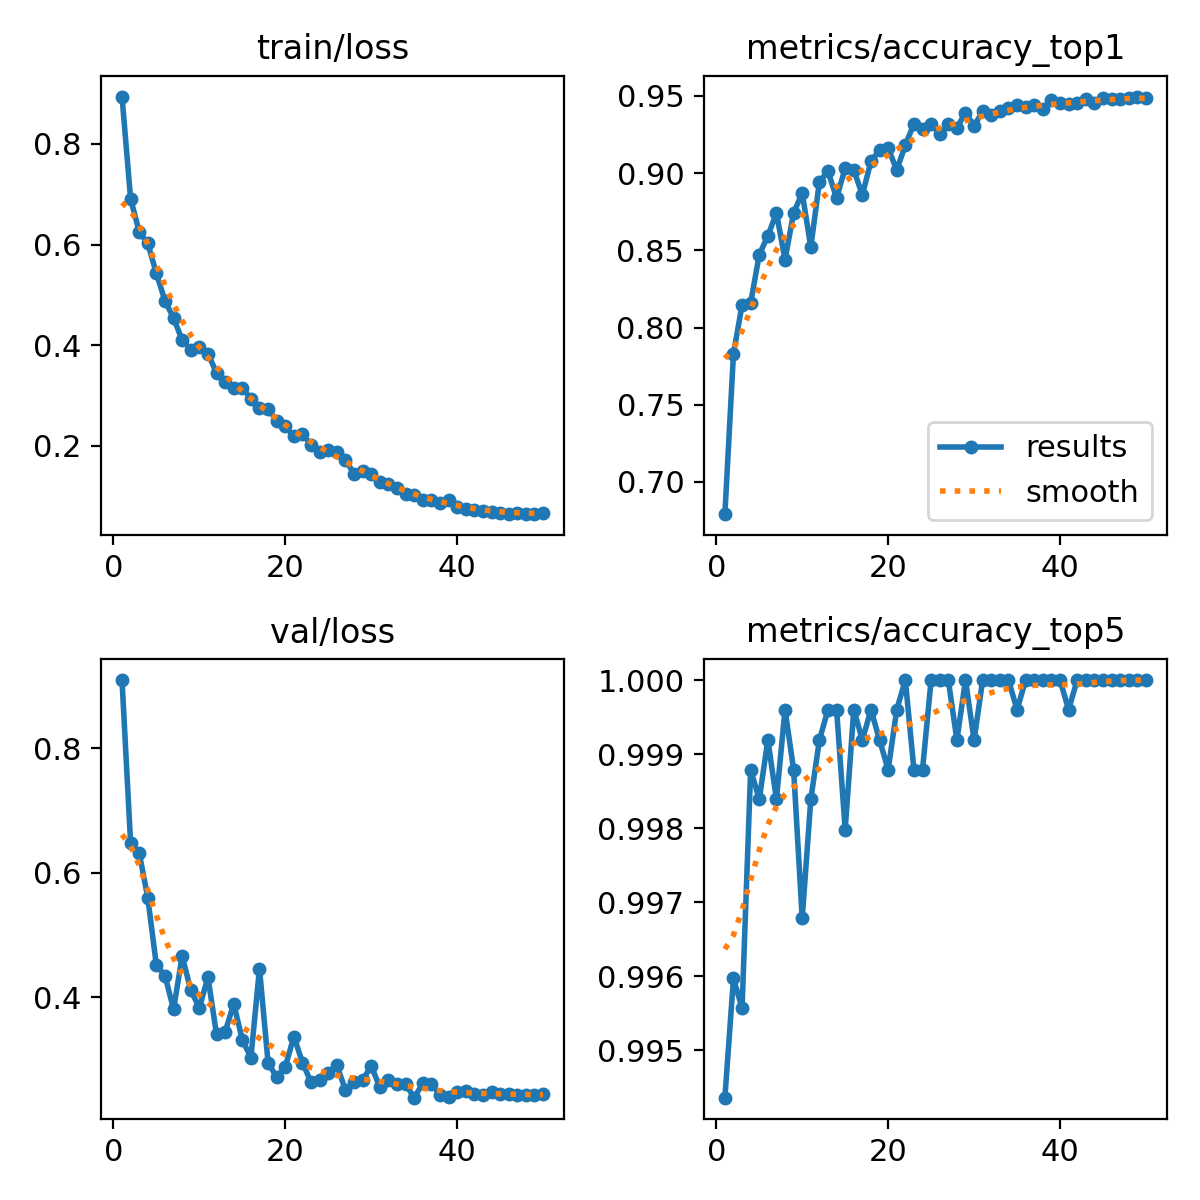

In [6]:
print("\n--- GRAFIK PERFORMA MODEL ---")
folder_hasil = "/content/drive/MyDrive/runs/EXP/Baseline-EXP"
path_grafik = os.path.join(folder_hasil, "results.png")

if os.path.exists(path_grafik):
    display(Image(filename=path_grafik, width=800))
else:
    print("Grafik performa tidak ditemukan.")

#Custom Graph

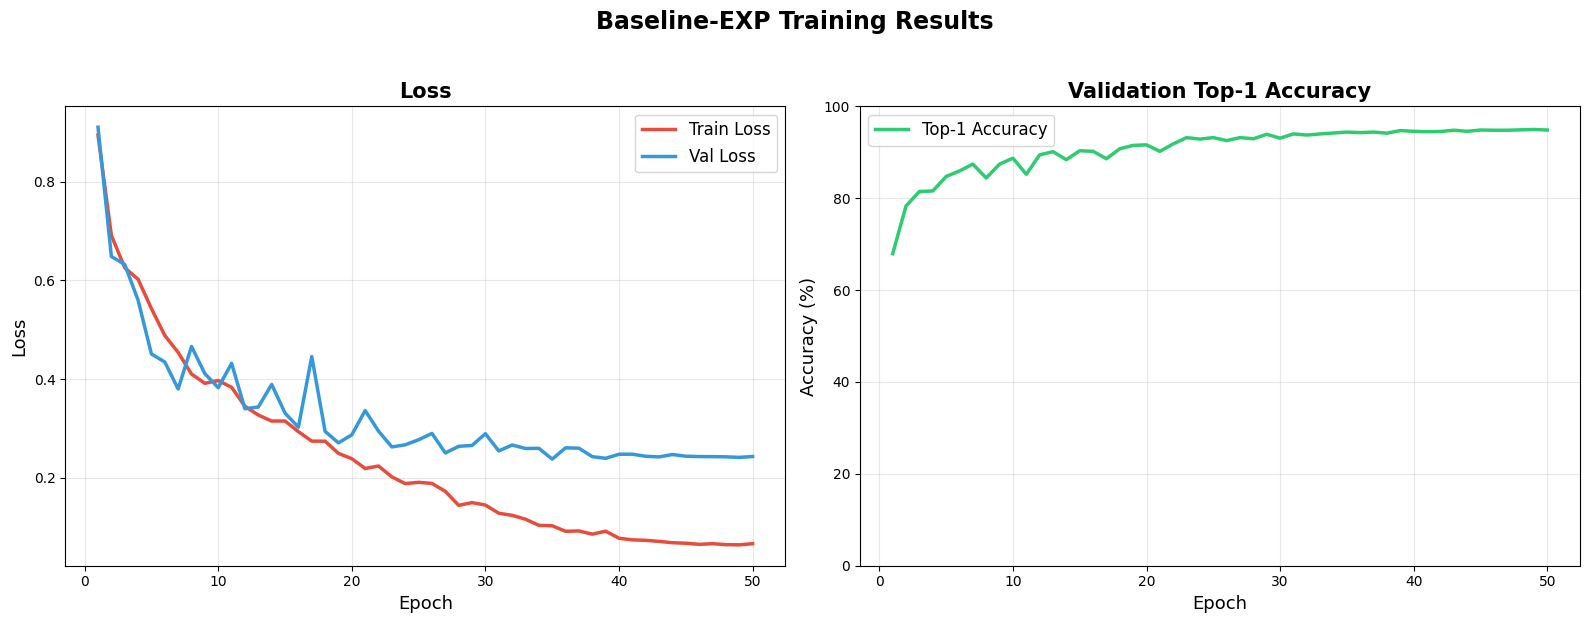

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

results_dir = "/content/drive/MyDrive/runs/EXP/Baseline-EXP"
df = pd.read_csv(f"{results_dir}/results.csv")
df.columns = df.columns.str.strip()  # Ultralytics CSV headers often have leading spaces

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df['epoch'], df['train/loss'], label='Train Loss', linewidth=2.5, color='#e74c3c')
if 'val/loss' in df.columns:
    axes[0].plot(df['epoch'], df['val/loss'], label='Val Loss', linewidth=2.5, color='#3498db')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Loss', fontsize=13)
axes[0].set_title('Loss', fontsize=15, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['epoch'], df['metrics/accuracy_top1'] * 100, label='Top-1 Accuracy', linewidth=2.5, color='#2ecc71')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Accuracy (%)', fontsize=13)
axes[1].set_title('Validation Top-1 Accuracy', fontsize=15, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Baseline-EXP Training Results', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f"{results_dir}/results_readable.png", dpi=150, bbox_inches='tight')
plt.show()

#Confusion Matrix

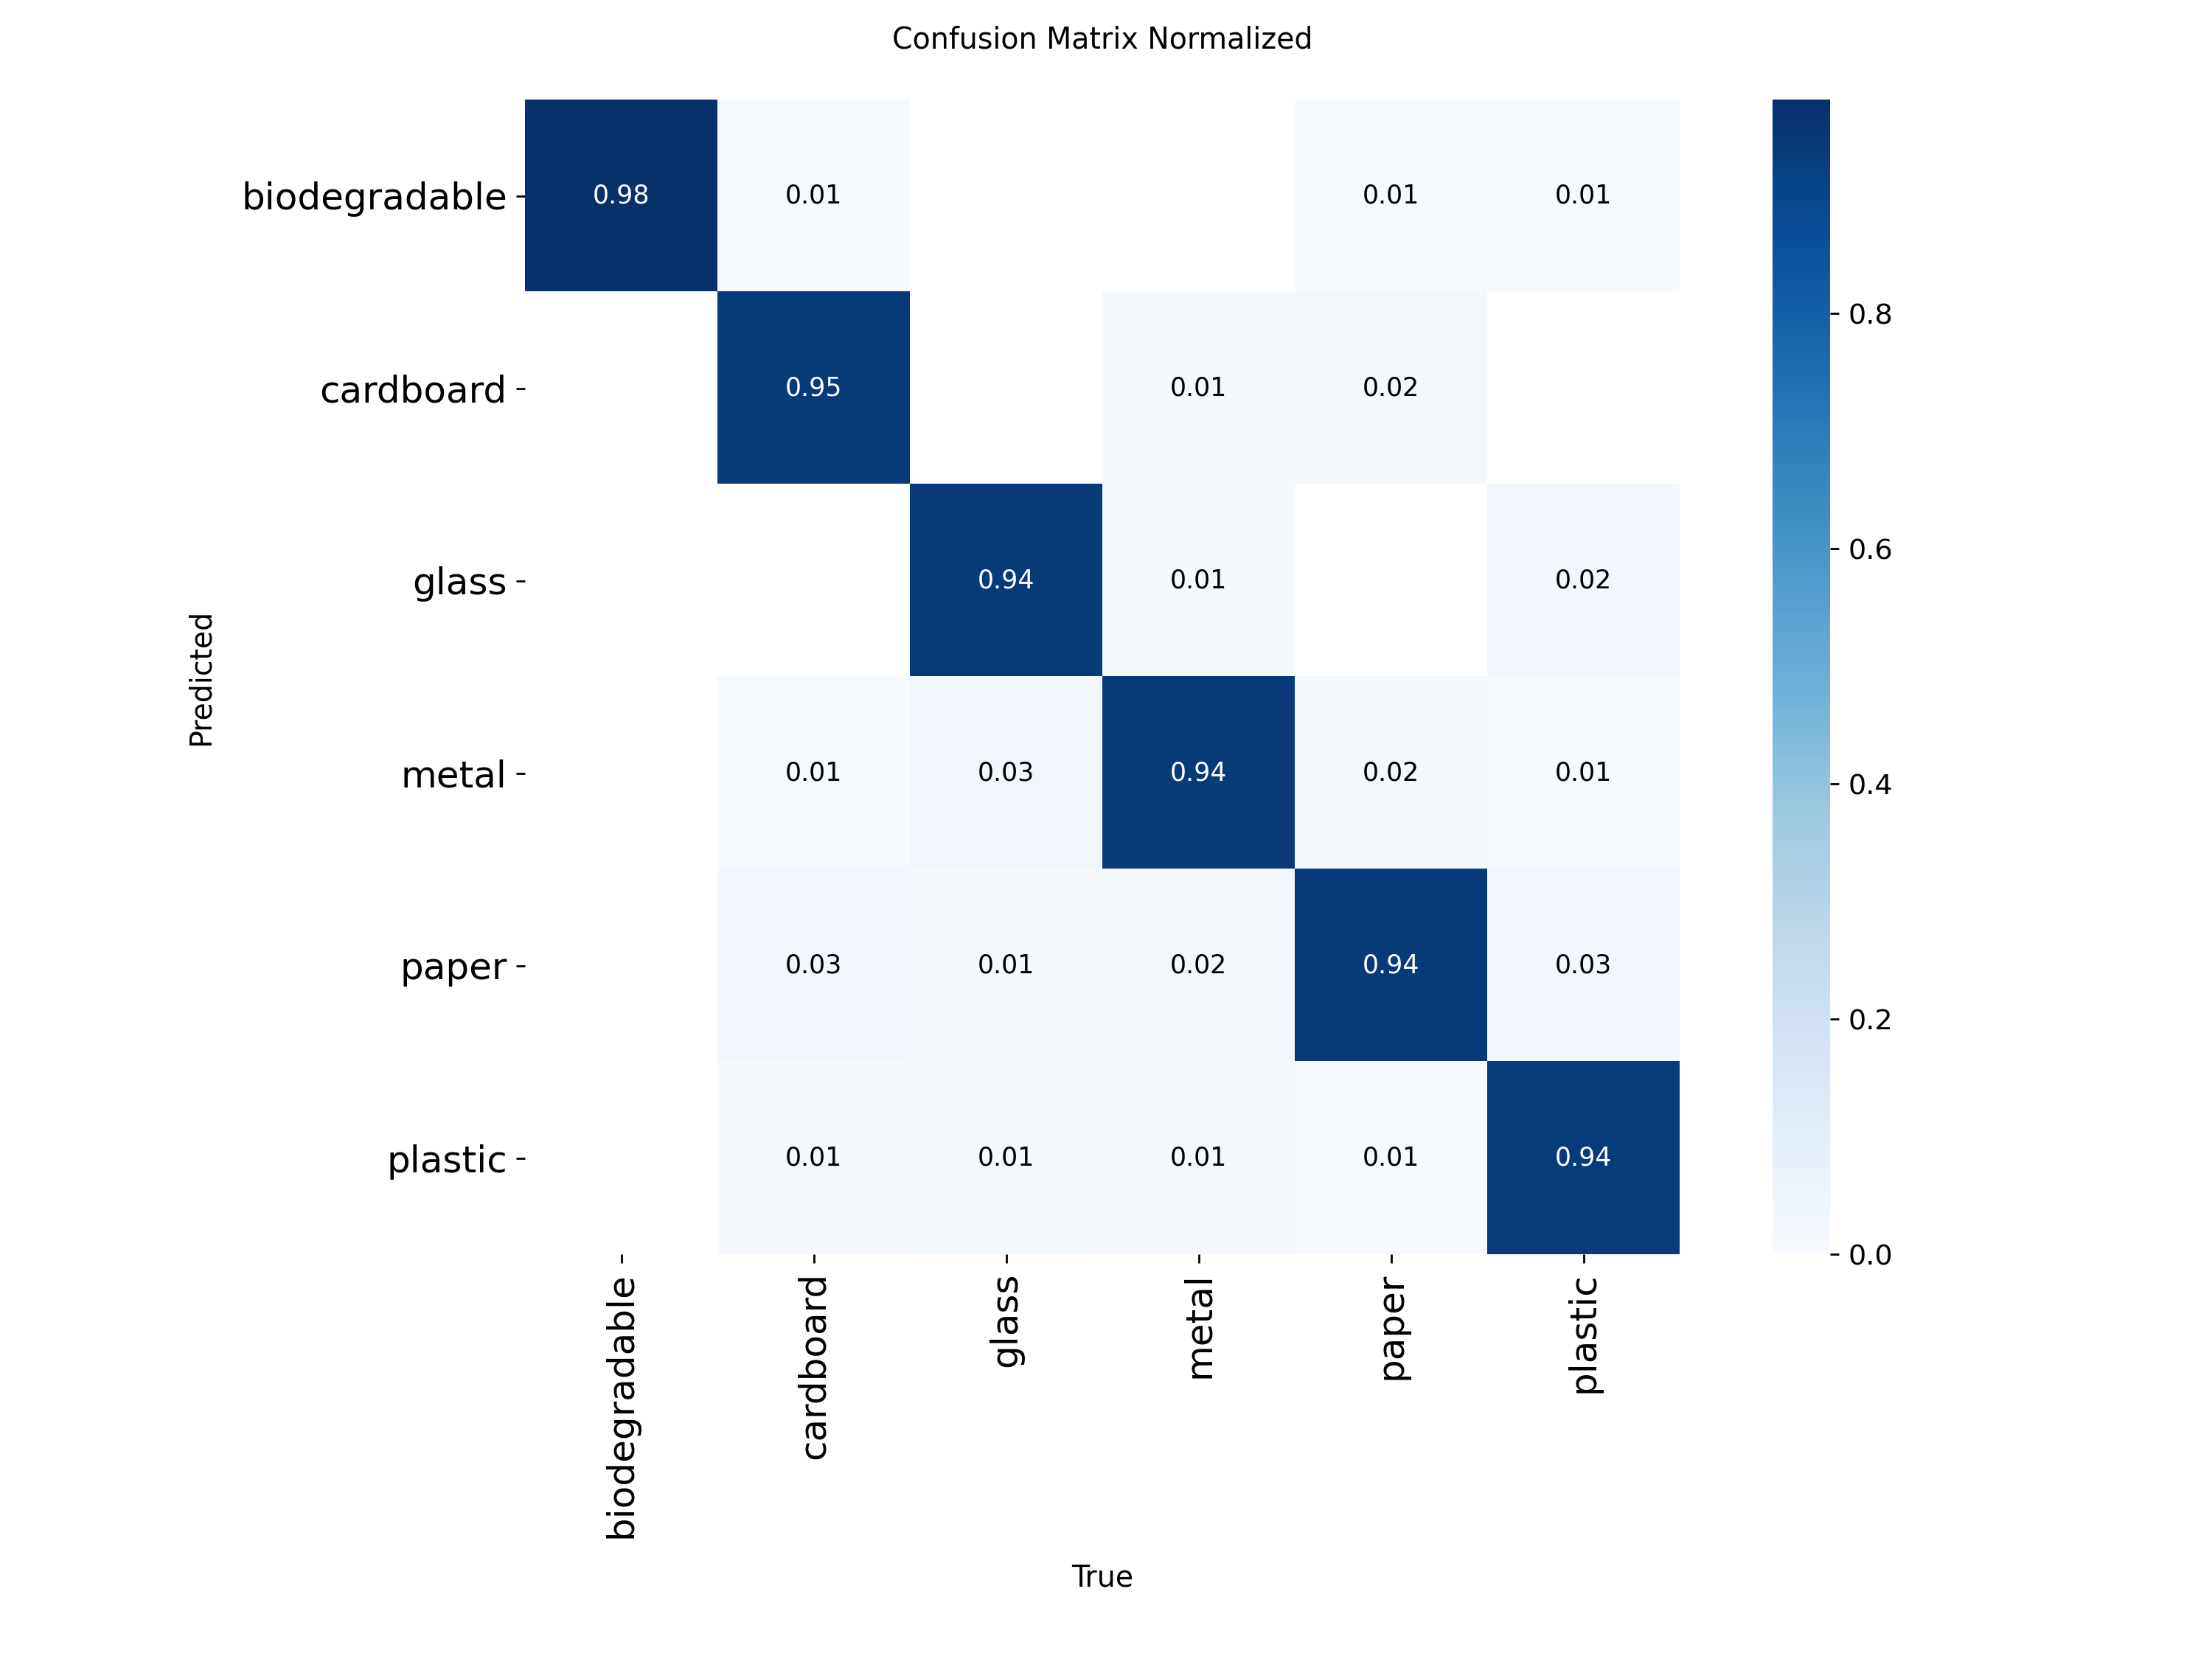

In [10]:
import os
from IPython.display import Image, display

cm_path = os.path.join(folder_hasil, "confusion_matrix_normalized.png") #confusion_matrix_normalized.png or confusion_matrix.png

if os.path.exists(cm_path):
    display(Image(filename=cm_path, width=800))
else:
    print("Confusion matrix not found at:", cm_path)

# Visualisasi Dengan Data Test 1-by-1

In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

model = YOLO("/content/drive/MyDrive/runs/EXP/Baseline-EXP/weights/best.pt")

test_folder = f"{dataset_path}/test"

for root, dirs, files in os.walk(test_folder):
    for file in files:
        if file.endswith((".jpg", ".png", ".jpeg")):
            image_path = os.path.join(root, file)
            results = model(image_path)

            probs = results[0].probs
            pred_class = results[0].names[probs.top1]
            confidence = float(probs.top1conf)
            true_class = os.path.basename(root)

            annotated = results[0].plot()

            plt.figure(figsize=(6, 6))
            plt.imshow(annotated[..., ::-1])
            plt.axis("off")
            plt.title(f"True: {true_class} | Pred: {pred_class} ({confidence:.1%})")
            plt.show()

# Visualisasi Dengan Data Test Batch

In [9]:
model = YOLO("/content/drive/MyDrive/runs/EXP/Baseline-EXP/weights/best.pt")

metrics = model.val(
    data=dataset_path,
    split='test',
    project="/content/drive/MyDrive/runs/EXP",
    name="Baseline-EXP-test"
)

print(f"Test Top-1 Accuracy: {metrics.top1:.2%}")
print(f"Test Top-5 Accuracy: {metrics.top5:.2%}")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-cls summary (fused): 47 layers, 1,533,710 parameters, 0 gradients, 3.2 GFLOPs
train: /content/Waste-Classifier-backup-1/train... found 8650 images in 6 classes ✅ 
val: /content/Waste-Classifier-backup-1/valid... found 2481 images in 6 classes ✅ 
test: /content/Waste-Classifier-backup-1/test... found 1219 images in 6 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 607.9±270.7 MB/s, size: 25.9 KB)
test: Scanning /content/Waste-Classifier-backup-1/test... 1219 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1219/1219 5.5Kit/s 0.2s
test: New cache created: /content/Waste-Classifier-backup-1/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 77/77 7.7it/s 10.0s
                   all      0.942          1
Speed: 0.4ms preprocess, 2.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/drive/MyDrive/runs/EXP/Baseline-EXP-test
Test Top-1 Accuracy: 9

# Coba dengan Gradio

In [ ]:
from ultralytics import YOLO
import gradio as gr

model = YOLO("/content/drive/MyDrive/runs/EXP/Baseline-EXP/weights/best.pt")

def predict(image):
    results = model(image)
    probs = results[0].probs
    return {results[0].names[i]: float(probs.data[i]) for i in range(len(probs.data))}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=6),
    title="Waste Sorting Classifier",
    description="Upload an image to classify it as biodegradable, glass, metal, paper, plastic, or cardboard."
)

demo.launch()


# Export Model untuk Deployment


In [ ]:
model = YOLO("/content/drive/MyDrive/runs/EXP/Baseline-EXP/weights/best.pt")

# Desktop, Server, Windows, Linux, Web, C++
model.export(format="onnx")

# Android, Raspberry Pi, Embedded, Device, IoT
model.export(format="tflite")

# Android
model.export(format="ncnn")

# iPhone, iPad, MacBook, Vision Pro, Apple Watch
model.export(format="coreml")
